# Practice Lab F: Probability Simulations

**Area:** probability · **Related lessons/concepts:** L07, L37, L48–L53; Quizzes 09, 13, 14

**You will be able to:**


In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. Law of large numbers: a fair coin

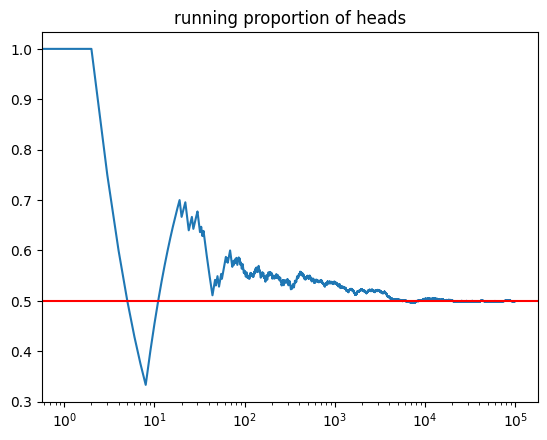

[0.4    0.56   0.503  0.4996]


In [2]:
rng=np.random.default_rng(0); flips=rng.integers(0,2,100000); run=np.cumsum(flips)/np.arange(1,len(flips)+1)
plt.plot(run); plt.axhline(.5,c='r'); plt.xscale('log'); plt.title("running proportion of heads"); plt.show(); print(run[[9,99,9999,99999]])

## 2. Dice: sum of two dice

In [3]:
r=rng.integers(1,7,(300000,2)).sum(1); sim=np.bincount(r,minlength=13)[2:]/len(r); exact=np.convolve(np.full(6,1/6),np.full(6,1/6))
print(np.round(sim,3)); print(np.round(exact,3)); print("max error",np.abs(sim-exact).max())

[0.028 0.056 0.083 0.111 0.139 0.167 0.139 0.111 0.083 0.056 0.028]
[0.028 0.056 0.083 0.111 0.139 0.167 0.139 0.111 0.083 0.056 0.028]
max error 0.0007033333333333336


## 3. Binomial vs simulation

In [4]:
from math import comb
n,p=10,0.75; exact=sum(comb(n,k)*p**k*(1-p)**(n-k) for k in range(6,11)); sim=(rng.binomial(n,p,200000)>5).mean(); print(exact,sim)   # 0.9219

0.9218730926513672 0.92087


## 4. Birthday problem

In [5]:
def sim_any(n,trials=20000): return np.mean([len(set(row))<n for row in rng.integers(0,365,(trials,n))])
for n in (10,23,40,57): print(n, round(sim_any(n),3), round(1-np.prod((365-np.arange(n))/365),3))

10 0.115 0.117
23 0.511 0.507
40 0.892 0.891
57 0.992 0.99


## 5. CLT with a skewed population

In [6]:
pop=rng.exponential(2,200000)
for n in (2,10,50): m=np.array([rng.choice(pop,n).mean() for _ in range(3000)]); print(n, "mean",round(m.mean(),3),"sd",round(m.std(),3),"theory",round(pop.std()/np.sqrt(n),3))

2 mean 1.974 sd 1.41 theory 1.413


10 mean 1.995 sd 0.629 theory 0.632
50 mean 2.008 sd 0.288 theory 0.283


## Exercises

**Exercise 1.** Estimate by simulation P(at least one 6 in 4 rolls) and compare with 1-(5/6)^4 = 0.5177.

In [7]:
# your code here

**Exercise 2.** Estimate P(sum of 3 dice = 10) and compare with 27/216 = 0.125.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
s=(rng.integers(1,7,(200000,4))==6).any(1).mean(); print(s); assert abs(s-0.5177)<0.01

0.517215


In [10]:
# Solution 2
s=(rng.integers(1,7,(300000,3)).sum(1)==10).mean(); assert abs(s-0.125)<0.005